In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

/home/michael/miniconda3/envs/kinase-docking-benchmark/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
torch.manual_seed(0)
torch.use_deterministic_algorithms(True)

# Load the data

The data was created in the docking benchmark study by [Schaller and Volkamer](https://raw.githubusercontent.com/openkinome/kinase-docking-benchmark/main/data/posit_results.csv).

In [3]:
df = pd.read_csv('../data/posit_results.csv')
df

,Unnamed: 0,protein_pdb_id,ligand_pdb_id,ligand_expo_id,pose,rmsd,docking_score,posit_probability,fingerprint_similarity,shape_similarity
0,kinoml_OEPositDockingFeaturizer_Human_PIM1_rcs...,5v80,2bik,BI1,1,6.089274,-15.456324,0.24,0.390805,0.947167
1,kinoml_OEPositDockingFeaturizer_Human_BTK_rcsb...,5p9h,4rx5,3YO,1,0.826982,-15.087384,0.78,0.478992,1.040043
2,kinoml_OEPositDockingFeaturizer_Human_AurA_rcs...,4zts,3p9j,P9J,1,9.800667,-11.544377,0.24,0.418605,0.604005
3,kinoml_OEPositDockingFeaturizer_Human_PIM1_rcs...,5kgk,3r02,UNM,1,0.693650,-12.181296,0.18,0.303030,0.749752
4,kinoml_OEPositDockingFeaturizer_Human_TRKA_rcs...,6d1y,5kmj,6UF,1,7.787918,-12.654554,0.33,0.503597,0.955698
...,...,...,...,...,...,...,...,...,...,...
41011,kinoml_OEPositDockingFeaturizer_Human_JAK2_rcs...,5l3a,4jia,1K3,1,7.302635,-10.504749,0.05,0.246154,0.605688
41012,kinoml_OEPositDockingFeaturizer_Human_JAK2_rcs...,3e62,6vne,2TA,1,2.922240,-9.482193,0.24,0.191176,0.468105
41013,kinoml_OEPositDockingFeaturizer_Human_AurA_rcs...,2w1f,4ceg,ADP,1,2.572326,-9.501300,0.24,0.184397,0.876073
41014,kinoml_OEPositDockingFeaturizer_Human_AurA_rcs...,5zan,3nrm,NRM,1,4.055761,-7.357885,0.18,0.346154,0.803240


# Feature analysis

First, we consider the correlations of features with the docking rmsd.

In [4]:
df[df['docking_score'] < 1e37][['docking_score', 'posit_probability', 'fingerprint_similarity', 'rmsd']].corr(numeric_only=True)

,docking_score,posit_probability,fingerprint_similarity,rmsd
docking_score,1.000000,0.123729,0.078959,0.101701
posit_probability,0.123729,1.000000,0.834550,-0.560715
fingerprint_similarity,0.078959,0.834550,1.000000,-0.441059
rmsd,0.101701,-0.560715,-0.441059,1.000000


In [5]:
df.dropna(inplace=True)

None of the features alone are great by themselves.

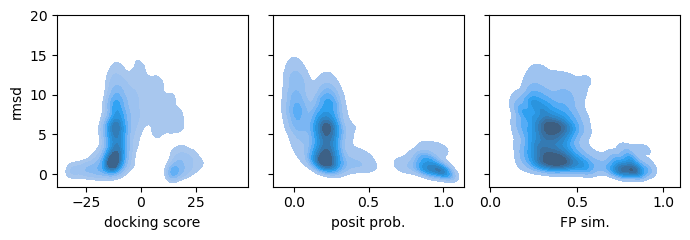

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharey=True, figsize=(7, 2.5))
sns.kdeplot(data=df[df['docking_score'] < 1e37], y='rmsd', x='docking_score', fill=True, ax=ax1)
ax1.set_xlabel('docking score')
sns.kdeplot(data=df, y='rmsd', x='posit_probability', fill=True, ax=ax2)
ax2.set_xlabel('posit prob.')
sns.kdeplot(data=df, y='rmsd', x='fingerprint_similarity', fill=True, ax=ax3)
ax3.set_xlabel('FP sim.')
plt.tight_layout()
plt.savefig('rmsd_v_stuff.pdf')

# RMSD prediction model

We will train a simple neural network to predict the docking RMSD, based on the benchmark data set.

In [7]:
X = torch.tensor(np.clip(df[['docking_score', 'fingerprint_similarity', 'posit_probability']].values, a_min=None, a_max=1000), dtype=torch.float)
y = torch.tensor(df['rmsd'].values, dtype=torch.float)

## Shuffle data

In [8]:
num_samples = X.shape[0]
shuffle_indices = torch.randperm(num_samples)
X = X[shuffle_indices]
y = y[shuffle_indices]

## Split data into training and testing sets

In [9]:
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size

X_train = X[:train_size]
y_train = y[:train_size]
X_test = X[train_size:]
y_test = y[train_size:]

In [10]:
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(3, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

Next, the optimization.

In [11]:
learning_rate = 0.001
num_epochs = 200
batch_size = 64

model = NN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [12]:
for epoch in range(num_epochs):
    for i in range(0, train_size, batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch.view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/200], Loss: 9.0947
Epoch [20/200], Loss: 8.8093
Epoch [30/200], Loss: 8.5269
Epoch [40/200], Loss: 7.8194
Epoch [50/200], Loss: 7.5012
Epoch [60/200], Loss: 7.4398
Epoch [70/200], Loss: 7.4116
Epoch [80/200], Loss: 7.4347
Epoch [90/200], Loss: 7.4567
Epoch [100/200], Loss: 7.4417
Epoch [110/200], Loss: 7.4256
Epoch [120/200], Loss: 7.4434
Epoch [130/200], Loss: 7.4472
Epoch [140/200], Loss: 7.4029
Epoch [150/200], Loss: 7.4270
Epoch [160/200], Loss: 7.4837
Epoch [170/200], Loss: 7.4491
Epoch [180/200], Loss: 7.3865
Epoch [190/200], Loss: 7.3693
Epoch [200/200], Loss: 7.3453


In [13]:
with torch.no_grad():
    model.eval()
    predicted = model(X_test)
    mse = criterion(predicted, y_test.view(-1, 1))
    correlation = torch.corrcoef(torch.stack([predicted.flatten(), y_test]))[1, 0]
    print(f'Mean Squared Error on Test Data: {mse.item():.4f}')
    print(f'Correlation on Test Data: {correlation.item():.4f}')

Mean Squared Error on Test Data: 5.9198
Correlation on Test Data: 0.6931


<Axes: xlabel='true rmsd', ylabel='predicted rmsd'>

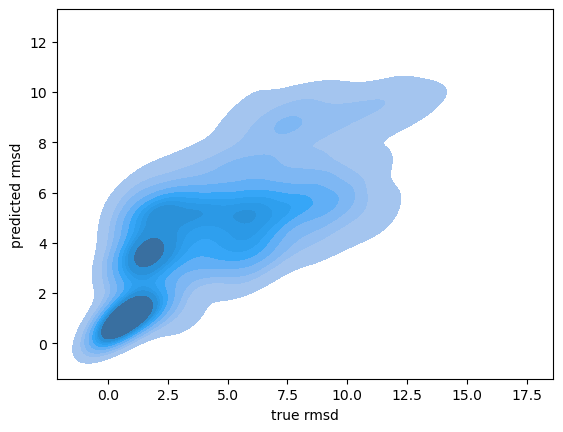

In [14]:
sns.kdeplot(data=pd.DataFrame({'predicted rmsd': predicted.flatten(), 'true rmsd': y_test.flatten()}), y='predicted rmsd', x='true rmsd', fill=True)

## Use the whole set for training

In [15]:
learning_rate = 0.001
num_epochs = 200
batch_size = 64

model = NN()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [16]:
for epoch in range(num_epochs):
    for i in range(0, train_size, batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch.view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/200], Loss: 9.1210
Epoch [20/200], Loss: 8.9684
Epoch [30/200], Loss: 8.7720
Epoch [40/200], Loss: 8.8238
Epoch [50/200], Loss: 8.5149
Epoch [60/200], Loss: 7.9727
Epoch [70/200], Loss: 7.7126
Epoch [80/200], Loss: 7.6227
Epoch [90/200], Loss: 7.4161
Epoch [100/200], Loss: 7.4495
Epoch [110/200], Loss: 7.4423
Epoch [120/200], Loss: 7.4257
Epoch [130/200], Loss: 7.4265
Epoch [140/200], Loss: 7.4629
Epoch [150/200], Loss: 7.4302
Epoch [160/200], Loss: 7.3756
Epoch [170/200], Loss: 7.4063
Epoch [180/200], Loss: 7.4129
Epoch [190/200], Loss: 7.3980
Epoch [200/200], Loss: 7.4287


In [17]:
torch.save(model.state_dict(), 'simple_nn_model.pth')